# 05. Prediction model

**Question:** how well can we predict home win / draw / away win after 90 minutes, using only what was known
before kickoff?

This notebook covers:
1. Choosing the Elo parameters, using the early seasons only.
2. Checking that the features can't see the match they're predicting.
3. Walk-forward results for each model.
4. Calibration and what the model gets wrong.

In [1]:
import sys
from pathlib import Path

# Let the notebook import from src/ when it's run from the notebooks folder.
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.database.connection import read_sql

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8, "axes.edgecolor": "#c3c2b7",
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left", "font.size": 10,
    "axes.prop_cycle": plt.cycler(color=["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]),
})
BLUE, ORANGE, GREEN, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#c3c2b7"

In [2]:
import itertools

from src.database.connection import get_engine
from src.features.elo import calculate_elo, elo_log_loss
from src.features.match_features import FEATURE_COLUMNS, build_match_features
from src.models.train import load_model_inputs

matches, club_stats = load_model_inputs(get_engine())
print(f"{(matches['status'] == 'finished').sum()} finished and {(matches['status'] == 'scheduled').sum()} scheduled matches")

1890 finished and 90 scheduled matches


## 1. Elo parameters

Elo has four settings: how fast ratings move (K), the home advantage, where new clubs start, and how much
ratings drift back to 1500 over the summer. They're chosen by a grid search that scores Elo's expected result
against what happened, **using only 2013-14 to 2015-16**. 2012-13 is a warm-up (every club starts from
scratch) and the model backtest starts in 2016-17, so this choice can't leak into the results below.

In [3]:
tuning = matches[matches["season_year"].between(2013, 2015)]
grid = []
for k, home, new, regression in itertools.product([20, 30, 40, 50, 60], [30, 60, 90, 120],
                                                  [1250, 1350, 1450], [0.1, 0.2, 0.3]):
    elo = calculate_elo(matches, k_factor=k, home_advantage=home, new_club_rating=new, season_regression=regression)
    grid.append({"k": k, "home": home, "new_club": new, "regression": regression,
                 "log_loss": elo_log_loss(tuning, elo, home_advantage=home)})
grid = pd.DataFrame(grid).sort_values("log_loss")
grid.head(8).round(4)

,k,home,new_club,regression,log_loss
127,50,90,1250,0.2,0.5835
91,40,90,1250,0.2,0.5838
128,50,90,1250,0.3,0.5845
90,40,90,1250,0.1,0.5847
130,50,90,1350,0.2,0.5847
163,60,90,1250,0.2,0.5848
126,50,90,1250,0.1,0.5849
136,50,120,1250,0.2,0.5849


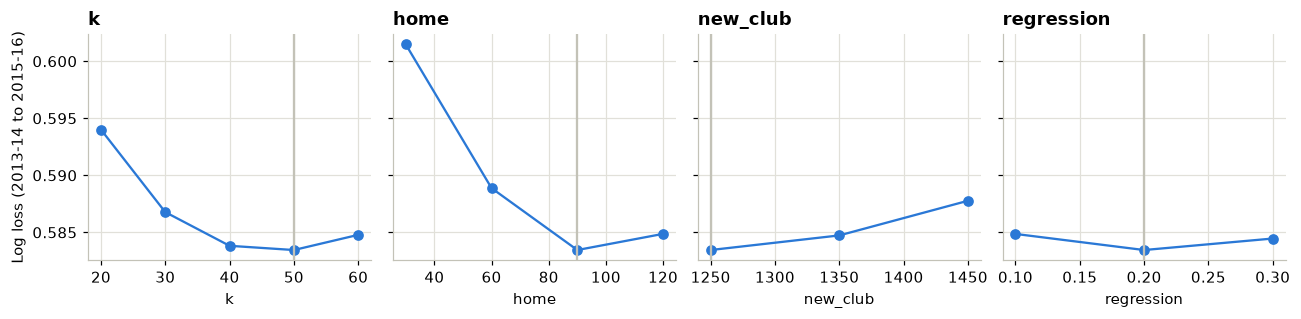

In [4]:
# Look at one setting at a time with the others held at the chosen values.
chosen = {"k": 50, "home": 90, "new_club": 1250, "regression": 0.2}
fig, axes = plt.subplots(1, 4, figsize=(12, 3), sharey=True)
for ax, (name, value) in zip(axes, chosen.items()):
    others = {key: val for key, val in chosen.items() if key != name}
    mask = np.logical_and.reduce([grid[key] == val for key, val in others.items()])
    line = grid[mask].sort_values(name)
    ax.plot(line[name], line["log_loss"], marker="o", color=BLUE)
    ax.axvline(value, color=GREY)
    ax.set(title=name, xlabel=name)
axes[0].set_ylabel("Log loss (2013-14 to 2015-16)")
plt.tight_layout()

The best settings are K = 50, home advantage = 90, new clubs at 1250 and a 20% pull back to 1500 each
summer. The surface is flat near the top (the best eight are within 0.0015 of each other), so the exact
values matter less than the rough region. These are the constants in `src/features/elo.py`.

New clubs starting far below 1500 makes sense: most clubs we haven't seen before came through qualifying
and lose a lot in their first season.

**One honest note.** Before running this search I'd used rough guesses (K = 20, home advantage 60, new
clubs at 1450). In the backtest, those guesses actually did very slightly better (logistic regression log
loss 0.939 against 0.941). The gap is tiny and within noise, and switching back now would mean choosing
settings by looking at the test seasons, which is exactly what the time-based split is meant to prevent.
So the tuned values stay.

## 2. Leakage check

The rule: a match's features may only use matches that kicked off earlier. A direct test is to change a
result and check that the features for that same match don't move, while later matches do.
(`tests/test_features.py` does the same thing on a small made-up example.)

In [5]:
elo = calculate_elo(matches)
features = build_match_features(matches, club_stats, elo)

target = matches[(matches["status"] == "finished") & (matches["season_year"] == 2024)].iloc[50]
changed = matches.copy()
changed.loc[changed["match_id"] == target["match_id"], ["home_goals", "home_goals_90"]] += 5
changed_features = build_match_features(changed, club_stats, calculate_elo(changed))

same_match = features.set_index("match_id").loc[target["match_id"], FEATURE_COLUMNS]
same_match_after = changed_features.set_index("match_id").loc[target["match_id"], FEATURE_COLUMNS]
print("Features for the changed match are identical:", same_match.equals(same_match_after))

later = features["kickoff_utc"] > target["kickoff_utc"]
moved = (features.loc[later, FEATURE_COLUMNS].fillna(0) != changed_features.loc[later, FEATURE_COLUMNS].fillna(0)).any(axis=1)
print(f"Later matches whose features changed: {moved.sum()}")

Features for the changed match are identical: True
Later matches whose features changed: 373


## 3. Walk-forward results

Each season from 2016-17 is predicted by models trained only on the seasons before it. The scores are stored
in the database by `src/models/train.py`.

In [6]:
evaluation = read_sql("SELECT * FROM model_evaluation")
weighted = evaluation.groupby("model_name").apply(
    lambda df: pd.Series({metric: np.average(df[metric], weights=df["n_matches"])
                          for metric in ["log_loss", "brier_score", "accuracy", "macro_f1"]}),
    include_groups=False,
).sort_values("log_loss")
weighted.round(4)

,log_loss,brier_score,accuracy,macro_f1
model_name,,,,
Logistic regression,0.9411,0.5526,0.5867,0.4288
Elo only,0.9438,0.5554,0.5758,0.4178
Random forest,0.9442,0.5551,0.5853,0.4259
Gradient boosting,1.0113,0.5850,0.5503,0.4339
Base rates,1.0465,0.6332,0.4650,0.2114


Logistic regression beats Elo only in 6 of 10 seasons


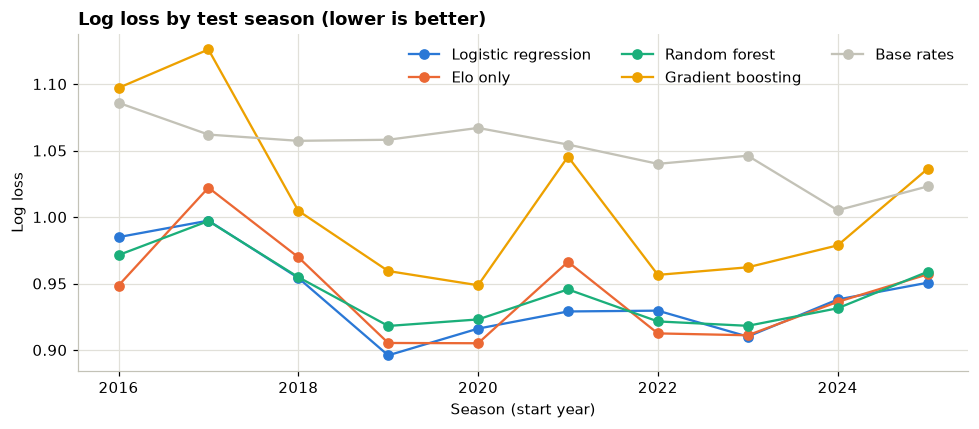

In [7]:
pivot = evaluation.pivot(index="test_season", columns="model_name", values="log_loss")
fig, ax = plt.subplots(figsize=(9, 4))
for name, color in [("Logistic regression", BLUE), ("Elo only", ORANGE), ("Random forest", GREEN),
                    ("Gradient boosting", "#eda100"), ("Base rates", GREY)]:
    ax.plot(pivot.index, pivot[name], marker="o", label=name, color=color)
ax.set(title="Log loss by test season (lower is better)", xlabel="Season (start year)", ylabel="Log loss")
ax.legend(frameon=False, ncol=3)
plt.tight_layout()

wins = (pivot["Logistic regression"] < pivot["Elo only"]).sum()
print(f"Logistic regression beats Elo only in {wins} of {len(pivot)} seasons")

- **Logistic regression** is best on every metric that matters (log loss 0.941, Brier 0.553), but only
  just ahead of **Elo only** (0.944), and it beats Elo in just 6 of the 10 seasons. Recent form, shots and
  the first-leg score add very little once the rating gap is known.
- **Random forest** is about as good as Elo only.
- **Gradient boosting** is clearly worse (1.011). With around 1,400 training matches it overfits even with
  shallow trees.
- Every model beats **base rates** (1.047), which only knows that home wins are the most common result.

So the simplest reasonable model wins. That's the one the dashboard uses by default.

## 4. Calibration and errors

Average predicted vs actual share:


,predicted,actual
Home win,0.479,0.465
Draw,0.212,0.199
Away win,0.310,0.336


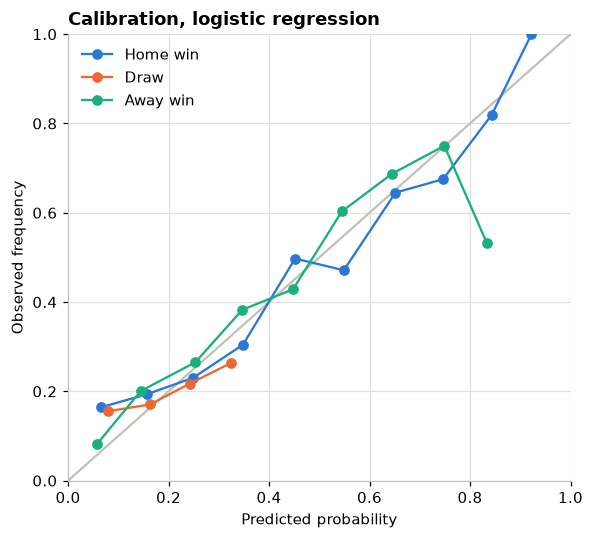

In [8]:
predictions = read_sql('''
    SELECT p.*, m.home_goals_90, m.away_goals_90
    FROM match_predictions p JOIN matches m ON m.match_id = p.match_id
    WHERE p.prediction_type = 'backtest' AND p.model_name = 'Logistic regression'
''')
predictions["actual"] = np.select(
    [predictions["home_goals_90"] > predictions["away_goals_90"], predictions["home_goals_90"] == predictions["away_goals_90"]],
    ["H", "D"], "A")

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 1], [0, 1], color=GREY)
for outcome, column, color in [("H", "p_home_win", BLUE), ("D", "p_draw", ORANGE), ("A", "p_away_win", GREEN)]:
    frame = pd.DataFrame({"p": predictions[column], "hit": (predictions["actual"] == outcome).astype(int)})
    frame["bin"] = pd.cut(frame["p"], np.linspace(0, 1, 11))
    grouped = frame.groupby("bin", observed=True).agg(p=("p", "mean"), hit=("hit", "mean"), n=("hit", "size"))
    grouped = grouped[grouped["n"] >= 15]
    ax.plot(grouped["p"], grouped["hit"], marker="o", color=color, label={"H": "Home win", "D": "Draw", "A": "Away win"}[outcome])
ax.set(title="Calibration, logistic regression", xlabel="Predicted probability", ylabel="Observed frequency",
       xlim=(0, 1), ylim=(0, 1))
ax.legend(frameon=False)
plt.tight_layout()

print("Average predicted vs actual share:")
pd.DataFrame({
    "predicted": predictions[["p_home_win", "p_draw", "p_away_win"]].mean().to_numpy(),
    "actual": [(predictions["actual"] == o).mean() for o in ["H", "D", "A"]],
}, index=["Home win", "Draw", "Away win"]).round(3)

Calibration is decent: when the model says 60%, that outcome happens roughly 60% of the time for both home
and away wins. On average it slightly overrates the home side (47.9% predicted against 46.5% actual) and
underrates away wins (31.0% against 33.6%). Home advantage has been a bit smaller since 2020-21 than in the
training seasons, which is a likely reason.

Draw probabilities never get much above 30%, so a draw is almost never the single most likely outcome and
draw recall is close to zero. That's normal for football models and a good reason to judge them on log
loss and calibration rather than accuracy.

## Conclusion

- Pre-match strength (Elo) explains most of what can be predicted; the extra features add very little.
- The best model gets about 59% of results right and gives reasonably calibrated probabilities.
- The features were checked for leakage directly, and the validation never trains on the season it tests.
- **What it can't see:** domestic form, injuries, rotation, suspensions, travel and team news. Upsets in
  the Champions League are common, and no model built on this data will change that.